In [24]:
import logging
import os
import sys
import traceback
from tqdm import tqdm 

from hydra import initialize, compose
import numpy as np
import pandas as pd
from omegaconf import DictConfig
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import torch

import sys 
sys.path.insert(0, "../../../../../shared_utils")
from experiment_utils import get_forward_model

from torch.utils.data import TensorDataset, DataLoader

In [2]:
with initialize(config_path="../../../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus"
                    ])

In [3]:
# config["paths"]["ct_classifier_path"] = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/cell_type_classifier/2026-04-08_00-00-38/easy-monkey-341_TargetPredictionModel.pkl" 

In [4]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [5]:
# Classify both training and validation anndata 

In [6]:
train_data_phi = flow_matching.train_data.state_data
valid_data_phi = flow_matching.validation_data['random_state=42-split_to_retrieve=0-test_size=0.3-K=3'].state_data

In [7]:
annot_train = np.array(flow_matching.train_data.adata.obs.index)
annot_valid = np.array(flow_matching.validation_data['random_state=42-split_to_retrieve=0-test_size=0.3-K=3'].adata.obs.index)

In [8]:
X_concat = torch.from_numpy(np.concatenate([train_data_phi, valid_data_phi], axis=0))
annot_concat = np.concatenate([annot_train, annot_valid])

## Tensor dataset for data 

In [9]:
target_prediction = forward_model.target_prediction_model
target_prediction.eval()

RescaledTargetPredictionModel(
  (resc_model): ModuleDict(
    (inv_params): IZNorm(
      (params): ModuleDict(
        (mean): ModelParam()
        (covariance): ModelParam()
      )
    )
    (fwd_params): ZNorm(
      (params): ModuleDict(
        (mean): ModelParam()
        (covariance): ModelParam()
      )
    )
    (model): PerturbationApproximatePosterior(
      (pert_approximate_posterior): ModuleDict(
        (encoder): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=26, out_features=128, bias=True)
              (1): ReLU()
              (2): Dropout(p=0.0, inplace=False)
            )
            (1): Sequential(
              (0): Linear(in_features=128, out_features=128, bias=True)
              (1): ReLU()
              (2): Dropout(p=0.0, inplace=False)
            )
            (2): Sequential(
              (0): Linear(in_features=128, out_features=64, bias=True)
              (1): Identity()
            )
  

In [10]:
dataloader = DataLoader(
    torch.utils.data.TensorDataset(X_concat), 
    batch_size=4026,
    shuffle=False
)

In [11]:
ct_predictions = []

with torch.no_grad():
    for batch in tqdm(dataloader):
        X_batch = batch[0].to(target_prediction_model.device)
        y_pred = target_prediction(X_batch)["cell_type"].argmax(1)
        ct_predictions.append(y_pred.cpu().detach().numpy())

100%|██████████| 12938/12938 [02:11<00:00, 98.26it/s] 


In [12]:
ct_predictions = np.concatenate(ct_predictions)

In [13]:
from sklearn.preprocessing import LabelEncoder

# Prepare label encoder
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [14]:
ct_predictions_str = classes[ct_predictions]

In [15]:
pd.DataFrame(ct_predictions_str).value_counts()

0          
MPP            8101034
GMP-Neutro     7960072
MgKEryPro1     7085117
LMPP-CLP       6533733
Early_GMP      4329486
GMP_cycling    4052824
EosBasMast2    3291886
EosBasMast1    2174120
MPP_MgkEry     2106143
MgKEryPro2     1770105
EryPro         1484568
CyclingPro1     930617
late_MgkPro     654521
pre_cDC2        348140
earlyMPP        228550
preProB         198050
MLP             179255
CD16Mono        142507
CD14Mono        129886
HSCs            127829
EosBasMast3      93095
CyclingPro2      80250
pre_cDC1         68762
ProB             15215
Name: count, dtype: int64

In [16]:
ct_predictions_str.shape

(52085765,)

In [17]:
annot_concat.shape

(52085765,)

In [18]:
X_concat.shape

torch.Size([52085765, 26])

Read and annotate real data 

In [19]:
adata_real = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_.h5ad")

In [20]:
adata_real.obs.loc[annot_concat, "cell_type"] = ct_predictions_str

In [ ]:
# adata_real_subset = sc.pp.subsample(adata_real, n_obs=100_000,  random_state=42, copy=True)

In [ ]:
# sc.tl.pca(adata_real_subset)
# sc.pp.neighbors(adata_real_subset)
# sc.tl.umap(adata_real_subset)

In [ ]:
# sc.pl.umap(adata_real_subset, color="cell_type", legend_loc="on data", s=20)

In [ ]:
# adata_real_subset = adata_real_subset[:, :20]

In [ ]:
# sc.tl.pca(adata_real_subset)
# sc.pp.neighbors(adata_real_subset)
# sc.tl.umap(adata_real_subset)

In [ ]:
# sc.pl.umap(adata_real_subset, color="cell_type", legend_loc="on data", s=20)

# Perform protocol analysis

In [25]:
# Cell types to keep 
to_keep = ["CD14Mono",
            "CD16Mono",
            "CyclingPro1",
            "CyclingPro2",
            "EosBasMast1",
            "EosBasMast2",
            "EosBasMast3",
            "EryPro",
            "HSCs",
            "ProB",
            "late_MgkPro",
            'GMP-Neutro',
            'preProB',
            'pre_cDC1']

In [27]:
protocol_columns = ["740-yp_[µm]", 
                   "mtg_[µm]", 
                   "rhflt3l_[ng_ml]", 
                   "gm-csf_[ng_ml]", 
                   "tpo_[ng_ml]",
                   "sr1_[nm]", 
                   "um171_[nm]", 
                   "um729_[µm]", 
                   "scf_[ng_ml]",
                   "butyzamide_[nm]",
                   "retinoic_acid_[µm]",
                   "ldl_[ng_ml]", 
                   "il3_[ng_ml]", 
                   "o2_[%]", 
                   "days_of_culture"]

We will create an AnnData with unique protocols as `.obs` dimensions

In [28]:
# Unique protocols 
obs_protocols = adata_real.obs.loc[:, protocol_columns].values.astype(float)
X_protocols = np.unique(obs_protocols, axis=0)

In [29]:
X_protocols

array([[  5., 100.,  10., ...,   0.,  20.,  13.],
       [  5., 100.,  10., ...,   0.,  20.,  15.],
       [  5., 100.,  10., ...,   0.,  20.,  21.],
       ...,
       [  5., 100.,  10., ...,   0.,  20.,  21.],
       [  5., 100.,  10., ...,   0.,  20.,  14.],
       [  5., 100.,  10., ...,   0.,  20.,  21.]], shape=(103, 15))

In [30]:
obs_protocols

array([[  5., 100.,  10., ...,   0.,  20.,  13.],
       [  5., 100.,  10., ...,   0.,  20.,  13.],
       [  5., 100.,  10., ...,   0.,  20.,  13.],
       ...,
       [  5., 100.,  10., ...,   0.,  20.,  14.],
       [  5., 100.,  10., ...,   0.,  20.,  14.],
       [  5., 100.,  10., ...,   0.,  20.,  14.]], shape=(52085765, 15))

Create hashes 

In [31]:
protocol_hashes = {}
for prot_number, protocol in enumerate(X_protocols):
    # Derive string from protocol 
    protocol_str = "_".join(list(protocol.astype(str)))
    # Hash it using the corresponding integer
    protocol_hashes[prot_number] = protocol_str

iprotocol_hases = {val:key for key,val in protocol_hashes.items()}

In [32]:
real_data_prot_id = []

for i in tqdm(range(obs_protocols.shape[0])):
    protocol_i_str = "_".join(obs_protocols[i].astype("str"))
    protocol_i_hash = iprotocol_hases[protocol_i_str]
    real_data_prot_id.append(protocol_i_hash)

100%|██████████| 52085765/52085765 [06:44<00:00, 128664.43it/s]


In [33]:
real_data_prot_id = np.array(real_data_prot_id)

In [34]:
adata_real.obs["protocol_hash"] = real_data_prot_id

In [35]:
# Obs 
cell_type_proportions = {cell_type: [] for cell_type in adata_real.obs.cell_type.unique()}

for i, unique_protocol in tqdm(enumerate(X_protocols)):
    idx = adata_real.obs.protocol_hash == i
    adata_protocol = adata_real[idx]
    proportions = adata_protocol.obs.cell_type.value_counts() / adata_protocol.shape[0]
    
    for cell_type in cell_type_proportions: 
        if cell_type in proportions.index.values:
            cell_type_proportions[cell_type].append(proportions[cell_type])
        else:
            cell_type_proportions[cell_type].append(0.0)

103it [01:00,  1.69it/s]


## Check results

In [36]:
proportion_df = pd.DataFrame(cell_type_proportions)

protocol_adata = sc.AnnData(X=np.log1p(X_protocols), obs=proportion_df)
protocol_adata.var.index = protocol_columns

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [37]:
argmax_protocols = np.argmax(protocol_adata.obs, axis=0)

In [38]:
adata_argmax = protocol_adata[argmax_protocols]
adata_argmax.obs["cell_type"] = np.array(adata_argmax.obs.columns)
adata_argmax.obs.drop(["cell_type"], axis=1).max(0)

/tmp/ipykernel_3675995/674136677.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_argmax.obs["cell_type"] = np.array(adata_argmax.obs.columns)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


MPP            0.770728
EosBasMast1    0.325668
Early_GMP      0.318768
MgKEryPro1     0.326186
GMP-Neutro     0.661333
preProB        0.008394
EosBasMast3    0.036158
pre_cDC2       0.058278
GMP_cycling    0.199659
LMPP-CLP       0.344255
MPP_MgkEry     0.491231
HSCs           0.063790
earlyMPP       0.018913
CyclingPro2    0.035964
CD14Mono       0.009986
MLP            0.020470
MgKEryPro2     0.450037
ProB           0.002196
EosBasMast2    0.383860
CyclingPro1    0.693834
pre_cDC1       0.011159
EryPro         0.263206
late_MgkPro    0.711528
CD16Mono       0.041586
dtype: float64

In [39]:
adata_argmax.obs.drop(["cell_type"], axis=1).max(0).loc[to_keep]

CD14Mono       0.009986
CD16Mono       0.041586
CyclingPro1    0.693834
CyclingPro2    0.035964
EosBasMast1    0.325668
EosBasMast2    0.383860
EosBasMast3    0.036158
EryPro         0.263206
HSCs           0.063790
ProB           0.002196
late_MgkPro    0.711528
GMP-Neutro     0.661333
preProB        0.008394
pre_cDC1       0.011159
dtype: float64

Max enriched proportions for the 500k dataset 

CD14Mono       0.007501 \
CD16Mono       0.043888 \
CyclingPro1    0.704545 \
CyclingPro2    0.032233 \
EosBasMast1    0.334009 \
EosBasMast2    0.408742 \
EosBasMast3    0.037866 \
EryPro         0.316938 \
HSCs           0.068761 \
ProB           0.002957 \
late_MgkPro    0.715066 \
GMP-Neutro     0.665340 \
preProB        0.010091 \
pre_cDC2       0.064441 

# Check distribution of proportions per cell type

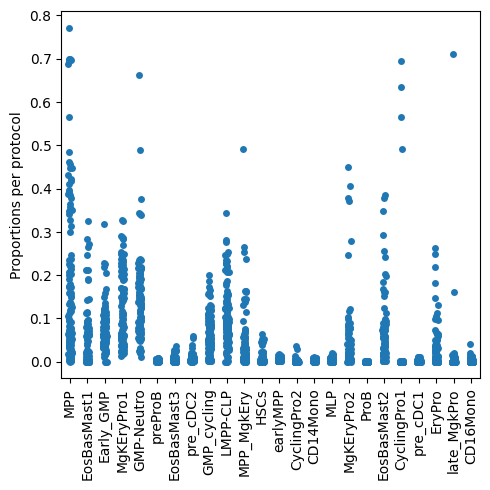

In [40]:
df = protocol_adata.obs.melt()

plt.figure(figsize=(5, 5))

sns.stripplot(
    data=df,
    x="variable",
    y="value",
    # showfliers=False  # cleaner look (optional)
)

plt.xticks(rotation=90)  # rotate labels
plt.xlabel("")
plt.ylabel("Proportions per protocol")
# plt.title("Proportions per protocols (103 unique protocols)", fontsize=14)

plt.tight_layout()
plt.show()

## Save adata 

In [45]:
protocol_adata.obs

,MPP,EosBasMast1,Early_GMP,MgKEryPro1,GMP-Neutro,preProB,EosBasMast3,pre_cDC2,GMP_cycling,LMPP-CLP,...,CD14Mono,MLP,MgKEryPro2,ProB,EosBasMast2,CyclingPro1,pre_cDC1,EryPro,late_MgkPro,CD16Mono
0,0.697537,0.013362,0.040323,0.026377,0.024751,0.003457,0.019766,0.004486,0.005884,0.077450,...,0.000889,0.004822,0.000910,0.000401,0.000715,0.000249,0.000065,0.000076,0.000043,0.000000
1,0.396100,0.052584,0.124992,0.060188,0.217160,0.002275,0.003575,0.000910,0.002210,0.045889,...,0.000325,0.001105,0.005460,0.000130,0.002405,0.000130,0.000130,0.000260,0.002730,0.000000
2,0.564265,0.002379,0.088879,0.044653,0.153724,0.008296,0.007076,0.003721,0.001220,0.042213,...,0.000061,0.000549,0.008601,0.002196,0.000793,0.000427,0.000061,0.000122,0.000000,0.000000
3,0.039255,0.063236,0.031108,0.022488,0.030695,0.000402,0.000174,0.003216,0.002779,0.032707,...,0.001809,0.000283,0.033468,0.000035,0.001593,0.000023,0.000066,0.023757,0.711528,0.000022
4,0.126013,0.017395,0.318768,0.041316,0.112202,0.002303,0.000937,0.000992,0.000740,0.082042,...,0.001056,0.000174,0.053756,0.000859,0.013067,0.000046,0.000155,0.064190,0.161804,0.000037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,0.082948,0.000644,0.064185,0.169651,0.187259,0.003291,0.001762,0.019983,0.155529,0.085736,...,0.002334,0.000542,0.004698,0.000072,0.202764,0.000395,0.001717,0.000564,0.000019,0.001974
99,0.022858,0.000015,0.000075,0.231301,0.131335,0.000109,0.000174,0.005589,0.039768,0.000093,...,0.000003,0.000559,0.003900,0.000018,0.055268,0.490117,0.003346,0.001354,0.004879,0.000015
100,0.001164,0.000009,0.000036,0.093537,0.102392,0.000029,0.001279,0.017127,0.007632,0.000029,...,0.000002,0.000033,0.000894,0.000024,0.072351,0.693834,0.001329,0.000529,0.000680,0.000148
101,0.006544,0.000000,0.000342,0.097580,0.190067,0.000079,0.000067,0.008471,0.022100,0.000018,...,0.000006,0.000134,0.000220,0.000012,0.097659,0.564103,0.000506,0.001220,0.002031,0.000268


In [46]:
protocol_adata.obs.max(0)

MPP            0.770728
EosBasMast1    0.325668
Early_GMP      0.318768
MgKEryPro1     0.326186
GMP-Neutro     0.661333
preProB        0.008394
EosBasMast3    0.036158
pre_cDC2       0.058278
GMP_cycling    0.199659
LMPP-CLP       0.344255
MPP_MgkEry     0.491231
HSCs           0.063790
earlyMPP       0.018913
CyclingPro2    0.035964
CD14Mono       0.009986
MLP            0.020470
MgKEryPro2     0.450037
ProB           0.002196
EosBasMast2    0.383860
CyclingPro1    0.693834
pre_cDC1       0.011159
EryPro         0.263206
late_MgkPro    0.711528
CD16Mono       0.041586
dtype: float64

In [47]:
protocol_adata.write_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/miscellaneous/unique_concentrations_adata_bloodplus.h5ad")